# Potato leaf disease classification

In [90]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from PIL import Image

In [91]:
IMG_SIZE = 32

X = []
y = []
files = []

for img_name in os.listdir('data/Healthy'):
    path = 'data/Healthy/' + img_name
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    X.append(np.array(img))
    y.append(0)
    files.append(path)

for img_name in os.listdir('data/potato'):
    path = 'data/potato/' + img_name
    img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    X.append(np.array(img))
    y.append(1)
    files.append(path)

X = np.array(X)
y = np.array(y)
files = np.array(files)

print(X.shape)
print(y.shape)

(712, 32, 32, 3)
(712,)


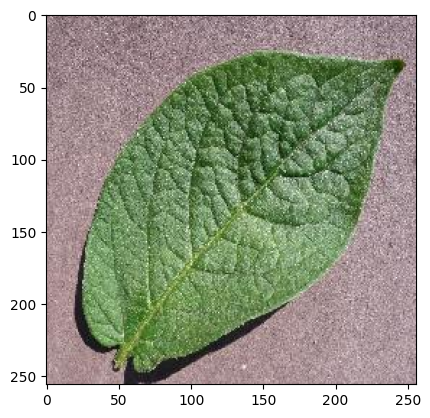

In [92]:
plt.imshow(Image.open('data/Healthy/' + os.listdir('data/Healthy')[0]))

In [93]:
y[0]

np.int64(0)

In [94]:
X = X / 255

In [95]:
np.random.seed(42)
idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]
files = files[idx]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
files_test = files[split:]

print(X_train.shape)
print(X_test.shape)

(569, 32, 32, 3)
(143, 32, 32, 3)


In [96]:
X_train_flattened = X_train.reshape(len(X_train), IMG_SIZE * IMG_SIZE * 3)
X_test_flattened = X_test.reshape(len(X_test), IMG_SIZE * IMG_SIZE * 3)

X_train_flattened.shape

(569, 3072)

Very simple neural network with no hidden layers

In [97]:
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(IMG_SIZE * IMG_SIZE * 3,), activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5


/home/sanjaya7/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7873 - loss: 0.4967  
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.4121 
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8629 - loss: 0.3446 
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8541 - loss: 0.3168 
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9297 - loss: 0.2484 


In [98]:
model.evaluate(X_test_flattened, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8252 - loss: 0.2942  


[0.2942393720149994, 0.8251748085021973]

In [99]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([0.9719078], dtype=float32)

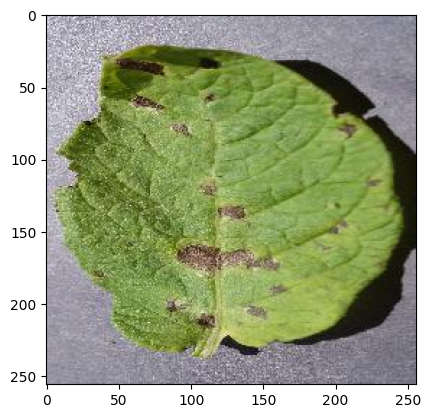

In [100]:
plt.imshow(Image.open(files_test[0]))

In [101]:
y_predicted_labels = [1 if p > 0.5 else 0 for p in y_predicted]
y_predicted_labels[:5]

[1, 1, 1, 1, 1]

Using hidden layer

In [102]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(IMG_SIZE * IMG_SIZE * 3,), activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flattened, y_train, epochs=5)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7504 - loss: 0.6633
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7891 - loss: 0.4227
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8225 - loss: 0.3505
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8541 - loss: 0.2879
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8981 - loss: 0.2415


In [103]:
model.evaluate(X_test_flattened, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9021 - loss: 0.2661 


[0.26609864830970764, 0.9020978808403015]

In [104]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [1 if p > 0.5 else 0 for p in y_predicted]

cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
cm

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 19,  13],
       [  1, 110]], dtype=int32)>

Text(58.222222222222214, 0.5, 'Truth')

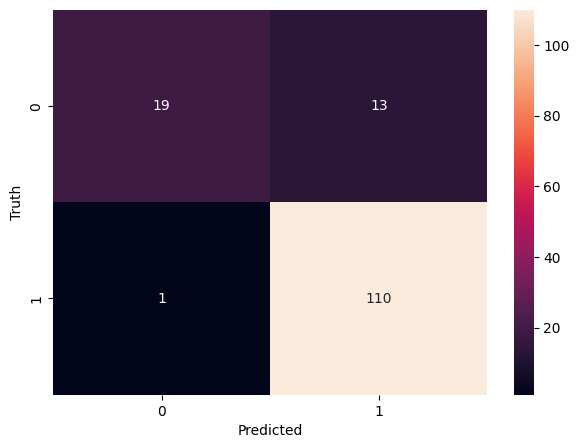

In [105]:
import seaborn as sn
plt.figure(figsize=(7, 5))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

Using Flatten layer so that we don't have to call .reshape on input dataset

In [106]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10)

Epoch 1/10


/home/sanjaya7/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8243 - loss: 0.5962
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8348 - loss: 0.3111 
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9139 - loss: 0.2401 
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9367 - loss: 0.1937 
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9543 - loss: 0.1516
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9402 - loss: 0.1535 
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9508 - loss: 0.1361 
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9736 - loss: 0.1124 
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9227 - loss: 0.1821 
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9561 - loss: 0.1121 


In [107]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9510 - loss: 0.1360  


[0.13598762452602386, 0.9510489702224731]